<a href="https://colab.research.google.com/github/nethuli-dev/traffic-accident-severity-prediction/blob/main/02_leakage_and_splits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/traffic-accident-severity-prediction
!git config --global --add safe.directory '*'
!pwd
!git pull

import os
for folder in ["data/raw", "data/processed", "reports/figures"]:
    os.makedirs(folder, exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

!ls -la

Mounted at /content/drive
/content/drive/MyDrive/traffic-accident-severity-prediction
/content/drive/MyDrive/traffic-accident-severity-prediction
Updating 055bbe0..08d24fa
error: Your local changes to the following files would be overwritten by merge:
	notebooks/02_leakage_and_splits.ipynb
Please commit your changes or stash them before you merge.
Aborting
total 24
drwx------ 4 root root 4096 Aug  5 05:52 data
drwx------ 8 root root 4096 Aug  5 06:57 .git
-rw------- 1 root root 1615 Aug  5 05:45 .gitignore
-rw------- 1 root root 1069 Aug  5 05:45 LICENSE
drwx------ 2 root root 4096 Aug  5 05:45 notebooks
-rw------- 1 root root  199 Aug  5 05:45 README.md
drwx------ 3 root root 4096 Aug  5 05:52 reports
-rw------- 1 root root    0 Aug  5 05:45 requirements.txt
drwx------ 2 root root 4096 Aug  5 05:45 src


In [2]:
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_e4fa88f4403f2b28a8581c324e0d96d6"
!kaggle datasets download -d sobhanmoosavi/us-accidents -p data/raw --unzip

Dataset URL: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents
License(s): CC-BY-NC-SA-4.0
100% 653M/653M [00:11<00:00, 61.3MB/s]



In [3]:
# Reload with dtype optimization and a fixed seed
bool_cols = [
    "Amenity", "Bump", "Crossing", "Give_Way", "Junction", "No_Exit", "Railway",
    "Roundabout", "Station", "Stop", "Traffic_Calming", "Traffic_Signal", "Turning_Loop"
]
float32_cols = [
    "Start_Lat", "Start_Lng", "End_Lat", "End_Lng", "Distance(mi)",
    "Temperature(F)", "Wind_Chill(F)", "Humidity(%)", "Pressure(in)",
    "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)"
]
category_cols = [
    "Source", "State", "Timezone", "Weather_Condition", "Wind_Direction",
    "Sunrise_Sunset", "Civil_Twilight", "Nautical_Twilight", "Astronomical_Twilight"
]

dtype_map = {}
for c in bool_cols: dtype_map[c] = "boolean"
for c in float32_cols: dtype_map[c] = "float32"
for c in category_cols: dtype_map[c] = "category"
dtype_map["Severity"] = "int8"

parse_dates = ["Start_Time", "End_Time", "Weather_Timestamp"]

np.random.seed(42)
DATA_PATH = "data/raw/US_Accidents_March23.csv"

df = pd.read_csv(DATA_PATH, dtype=dtype_map, parse_dates=parse_dates, low_memory=False,
                  skiprows=lambda i: i > 0 and np.random.rand() > 0.15)

for col in ["Start_Time", "End_Time", "Weather_Timestamp"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

print(df.shape)
print("Memory:", round(df.memory_usage(deep=True).sum() / 1e9, 2), "GB")

(1159461, 46)
Memory: 0.72 GB


In [4]:
#Saved to the drive
df.to_parquet("data/processed/accidents_sample.parquet", index=False)
print(f"Saved {df.shape[0]:,} rows to data/processed/accidents_sample.parquet")

!ls -la data/processed

Saved 1,159,461 rows to data/processed/accidents_sample.parquet
total 161760
-rw------- 1 root root 112675601 Aug  5 07:04 accidents_sample.parquet
-rw------- 1 root root  10292382 Aug  5 06:57 test.parquet
-rw------- 1 root root  31325049 Aug  5 06:31 train.parquet
-rw------- 1 root root  11347719 Aug  5 06:31 val.parquet


In [5]:
#Leakage Audit Table(Initial Hypothesis)
leakage_audit = [
    {"feature": "Distance(mi)", "known_at_prediction_time": False,
     "reason": "Length of road affected — measured/finalized after the incident is resolved, not at first report."},
    {"feature": "End_Time", "known_at_prediction_time": False,
     "reason": "When the incident cleared — only known after it's over."},
    {"feature": "End_Lat", "known_at_prediction_time": False,
     "reason": "Depends on End_Time/final extent of the incident."},
    {"feature": "End_Lng", "known_at_prediction_time": False,
     "reason": "Same as End_Lat."},
    {"feature": "Description", "known_at_prediction_time": False,
     "reason": "Free-text description often written/updated after responders assess the scene — risk of describing the outcome, not just the trigger."},
]

leakage_df = pd.DataFrame(leakage_audit)
print(leakage_df.to_string(index=False))

     feature  known_at_prediction_time                                                                                                                                reason
Distance(mi)                     False                                     Length of road affected — measured/finalized after the incident is resolved, not at first report.
    End_Time                     False                                                                               When the incident cleared — only known after it's over.
     End_Lat                     False                                                                                     Depends on End_Time/final extent of the incident.
     End_Lng                     False                                                                                                                      Same as End_Lat.
 Description                     False Free-text description often written/updated after responders assess the scene — risk of describi

Spearman correlation, duration_minutes vs Severity: -0.175


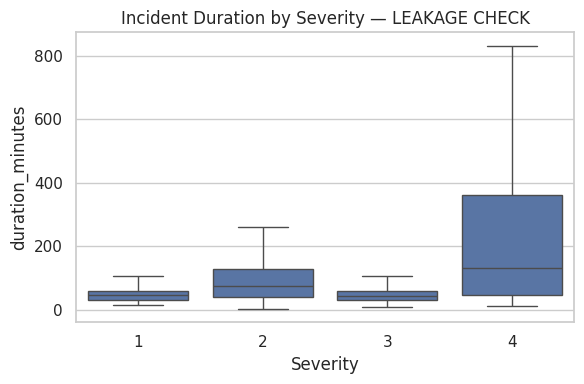

In [6]:
#Quantify the End_Time/duration leak
df["duration_minutes"] = (df["End_Time"] - df["Start_Time"]).dt.total_seconds() / 60

duration_corr = df[["duration_minutes", "Severity"]].corr(method="spearman").iloc[0, 1]
print(f"Spearman correlation, duration_minutes vs Severity: {duration_corr:.3f}")

plt.figure(figsize=(6, 4))
sns.boxplot(x="Severity", y="duration_minutes", data=df, showfliers=False)
plt.title("Incident Duration by Severity — LEAKAGE CHECK")
plt.tight_layout()
plt.savefig("reports/figures/duration_leakage_check.png", dpi=150)
plt.show()


In [7]:
#Check the weather timestamp gap
df["weather_time_gap_min"] = (df["Weather_Timestamp"] - df["Start_Time"]).dt.total_seconds() / 60

print(df["weather_time_gap_min"].describe())

pct_after = (df["weather_time_gap_min"] > 30).mean() * 100
print(f"\n% of rows where weather reading is >30 min AFTER accident start: {pct_after:.2f}%")

count    1.031897e+06
mean     6.034330e-01
std      3.994703e+01
min     -1.363000e+03
25%     -1.120000e+01
50%      0.000000e+00
75%      1.138333e+01
max      1.432000e+03
Name: weather_time_gap_min, dtype: float64

% of rows where weather reading is >30 min AFTER accident start: 1.31%


In [8]:
#finalized leakage decision table
leakage_audit_final = [
    {"feature": "Distance(mi)", "keep": False,
     "reason": "Length of road affected — only finalized after the incident resolves; not available at report time."},
    {"feature": "End_Time", "keep": False,
     "reason": "Only known once incident clears."},
    {"feature": "End_Lat", "keep": False,
     "reason": "Derived from End_Time/final extent of incident."},
    {"feature": "End_Lng", "keep": False,
     "reason": "Same as End_Lat."},
    {"feature": "duration_minutes", "keep": False,
     "reason": f"Severity 4 accidents show visibly longer duration (median ~150min vs ~50-80min for Severity 1-3); only known post-hoc, engineered leak — drop it too."},
    {"feature": "Description", "keep": False,
     "reason": "Free text risks describing outcome, not just cause; excluded for this modeling phase."},
    {"feature": "Weather_Timestamp / weather fields", "keep": True,
     "reason": f"Median gap to Start_Time is 0 minutes; only 1.31% of rows have readings >30min after accident start — safe to treat as known at report time."},
]

leakage_final_df = pd.DataFrame(leakage_audit_final)
leakage_final_df.to_csv("reports/leakage_audit.csv", index=False)
print(leakage_final_df.to_string(index=False))

                           feature  keep                                                                                                                                                reason
                      Distance(mi) False                                                   Length of road affected — only finalized after the incident resolves; not available at report time.
                          End_Time False                                                                                                                      Only known once incident clears.
                           End_Lat False                                                                                                       Derived from End_Time/final extent of incident.
                           End_Lng False                                                                                                                                      Same as End_Lat.
                  duration_minutes False Seve

In [9]:
#Drop the confirmed leaking columns
leak_cols_to_drop = ["Distance(mi)", "End_Time", "End_Lat", "End_Lng",
                      "duration_minutes", "weather_time_gap_min", "Description"]

df_clean = df.drop(columns=leak_cols_to_drop)
print(f"Dropped {len(leak_cols_to_drop)} leaking columns.")
print(f"Remaining shape: {df_clean.shape}")

Dropped 7 leaking columns.
Remaining shape: (1159461, 41)


## Leakage Audit — Summary

We identified and removed six columns that would not realistically be available
at the moment an accident is first reported, and would therefore leak future
information into the model:

- **Distance(mi), End_Lat, End_Lng, End_Time** — these describe the final extent
  and resolution of the incident, only known once it has been fully cleared.
- **duration_minutes** (engineered) — confirmed via boxplot that Severity 4
  accidents have a visibly longer duration (median ~150 min) than Severity 1-3
  (~50-80 min). Since duration is only known after the incident ends, this is a
  clear leak that mirrors the same issue as End_Time.
- **Description** — free-text notes are often written or updated after responders
  assess the scene, risking descriptions of the outcome rather than the cause.

We also tested whether **weather fields** were a leakage risk, since weather
readings could theoretically reflect conditions after an accident occurred.
The median gap between `Weather_Timestamp` and `Start_Time` was 0 minutes, and
only 1.31% of rows had a gap greater than 30 minutes — so weather features were
kept as legitimate, available-at-report-time predictors.

Full audit table saved to `reports/leakage_audit.csv`.

In [10]:
#Adding a year column and see how data is spread across years
df_clean["year"] = df_clean["Start_Time"].dt.year
print(df_clean["year"].value_counts().sort_index())

year
2016.0     61807
2017.0    107518
2018.0    133820
2019.0    143407
2020.0    174238
2021.0    211952
2022.0    190274
2023.0     24871
Name: count, dtype: int64


In [11]:
#Split by time, not randomly
train_df = df_clean[df_clean["year"] <= 2020]
val_df   = df_clean[df_clean["year"] == 2021]
test_df  = df_clean[df_clean["year"] == 2022]

print(f"Train: {train_df.shape[0]:,} rows ({train_df['year'].min()}-{train_df['year'].max()})")
print(f"Val:   {val_df.shape[0]:,} rows ({val_df['year'].min()}-{val_df['year'].max()})")
print(f"Test:  {test_df.shape[0]:,} rows ({test_df['year'].min()}-{test_df['year'].max()})")

Train: 620,790 rows (2016.0-2020.0)
Val:   211,952 rows (2021.0-2021.0)
Test:  190,274 rows (2022.0-2022.0)


## Why a Time-Based Split, Not Random K-Fold

We split the data by year (train: 2016-2020, validation: 2021, test: 2022) rather
than using a random row-level split or standard k-fold cross-validation.

A random split would let the model "see" accidents from the same time period it's
later tested on, which does not reflect how the model would actually be used in
practice — predicting outcomes for accidents that haven't happened yet, using
patterns learned from the past. A time-based split forces the model to prove it
generalizes forward in time, which is a more honest test of real-world performance.

In [12]:
#Sanity check on the split(check nothing looks broken)
for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"\n{name} severity distribution:")
    print(split["Severity"].value_counts(normalize=True).round(3).sort_index())


Train severity distribution:
Severity
1    0.007
2    0.704
3    0.259
4    0.030
Name: proportion, dtype: float64

Val severity distribution:
Severity
1    0.000
2    0.876
3    0.105
4    0.019
Name: proportion, dtype: float64

Test severity distribution:
Severity
1    0.030
2    0.885
3    0.062
4    0.024
Name: proportion, dtype: float64


## Finding: Severity Class Distribution Shifts Non-Monotonically Across Years

While checking the train/val/test splits, we found that the proportion of each
severity class shifts substantially and unevenly across years:

| Severity | 2016-2020 | 2021 | 2022 |
|---|---|---|---|
| 1 | 0.7% | 0.0% | 3.0% |
| 2 | 70.4% | 87.6% | 88.5% |
| 3 | 25.9% | 10.5% | 6.2% |
| 4 | 3.0% | 1.9% | 2.4% |

This pattern is not a smooth trend — Severity 1 drops to 0% in 2021 before rising
again to 3.0% in 2022 — which suggests a change in data collection methodology or
contributing sources over time, rather than a genuine shift in real-world accident
severity. We tested an alternative split (train through 2021, test on 2023) and
found the same instability, including a test set with *no* Severity 1 or 3
examples at all — confirming this is a dataset-wide characteristic, not isolated
to one particular cutoff year.

**Implication for later phases:** during error analysis, we will evaluate model
performance broken down by year, not just as a single aggregate test score, since
part of any train-test performance gap may reflect this underlying distribution
shift rather than pure model generalization failure.

In [13]:
#Save the splits
train_df.to_parquet("data/processed/train.parquet", index=False)
val_df.to_parquet("data/processed/val.parquet", index=False)
test_df.to_parquet("data/processed/test.parquet", index=False)
print("Saved train/val/test splits.")

Saved train/val/test splits.
